# KIN 482D: Computational modeling of human sensorimotor control and learning

## Chapter 5: Cue combination and evidence accumulation

## Housekeeping

- Final projects
    - Individual meetings after Midterm Break
- Problem Set 4
    - Problems: 5.1, 5.2, 5.5(a-c), 5.6, 5.7 
- Midterm Exam is next week 
    - Monday review session
- We received a request to be out of room by 1:50 this week - next class needs to set-up for a lab exam
    

## Big question of this chapter

*How can we integrate multiple sensory inputs ("cues") into a single percept?*

This is the fundamental question underlying multisensory integration. 

Real world examples: 
- Localizing limb position given visual and proprioceptive cues
- Localizing a bouncing basketball given visual and auditory cues
- Intepreting where a conversation is coming from through visual and auditory cues from your TV
- Identifying a food from its smell and taste
- Estimating our acceleration in a moving vehicle can involve vision, proprioception, and our vestibular sense
- Non-multisensory integration example involving cue combination: In vision we use color, texture, and depth to identify an object
- The point is that it's everywhere and happening virtually all of the time

<center><img src="images/bounce-pass.png" width=600></center>

## Plan

- Discuss intuitions behind cue combination
- Develop Steps 1 through 3 of Bayesian inference for cue combination
- Show how integration of sensory evidence over time is mathematically equivalent to cue combination
- Discuss empirical literature on humans using cue combination

## Question

If one sensory modality is much more precise than another, should we just go with the more reliable cue and ignore the other? Why or why not? 

## Why combine cues? Or, why not just go with the most reliable cue? 

- Even our most reliable sense vision has uncertainty associated with it
- Paying attention to only the most reliable cue ("Winner-take-all" model) means ignoring a cue, which is akin to discarding useful information 
- The best strategy is to combine all possible sources of information in an optimal manner (which we'll specify in a bit) - this will lead to more precise estimates
- Combining cues can also resolve ambiguities 
    - Inferring an object's identity by shape alone may be difficult because many different objects may have similar shapes 
    - A spherical object is consistent with peaches and oranges
    - Proprioception can tell us about the shape, while mechanoreceptors can tell us about texture
    

<center><img src="images/fig5-1.png" width=600></center>

Speaker produces brief auditory tone at the same time an LED lights up. Subject uses a laser pointer to indicate the perceived position of the tone. 

## Step 1: The graphical generative model
<center><img src="images/fig5-2.png" width=300></center>

## Conditional independence

- The auditory and visual measurements are independent of each other *when conditioned on the true stimulus*. We can't say they are independent of each other because when the auditory measurement is left, the visual measurement will tend to be left as well (and vice versa). However, we assume that on repeated presentations of the *same stimulus*, the trial-by-trial variability in the auditory and visual measurements will be uncorrelated. 

- Mathematically: 

\begin{align}
p(x_1, x_2|s) &= p(x_1|x_2, s)p(x_2|s) = p(x_2|x_1, s)p(x_1|s) \space [\text{General axiom of probability theory.}] \\
              &= p(x_1|s)p(x_2|s) \space [\text{Only if conditionally independent.}] \\
p(x_1, x_2)   &= p(x_1)p(x_2) \space [\text{Only if truly independent.}]
\end{align}


**Possible board time for Box 5.1.**

- Conditional independence occurs when 2 RVs are independent only given the value of a third RV.
- Examples: 
    - Having Alzheimer's and needing reading glasses are not independent because they both occur more frequently in elderly. However, among only 80-year olds (i.e., given the age group), the two are probably more or less independent. 
    - Homicide rates and ice cream sales are correlated; however, they are independent when given (conditioned on) temperature
- Intuition is that you condition on the value of the cause of dependence of the two variables.  

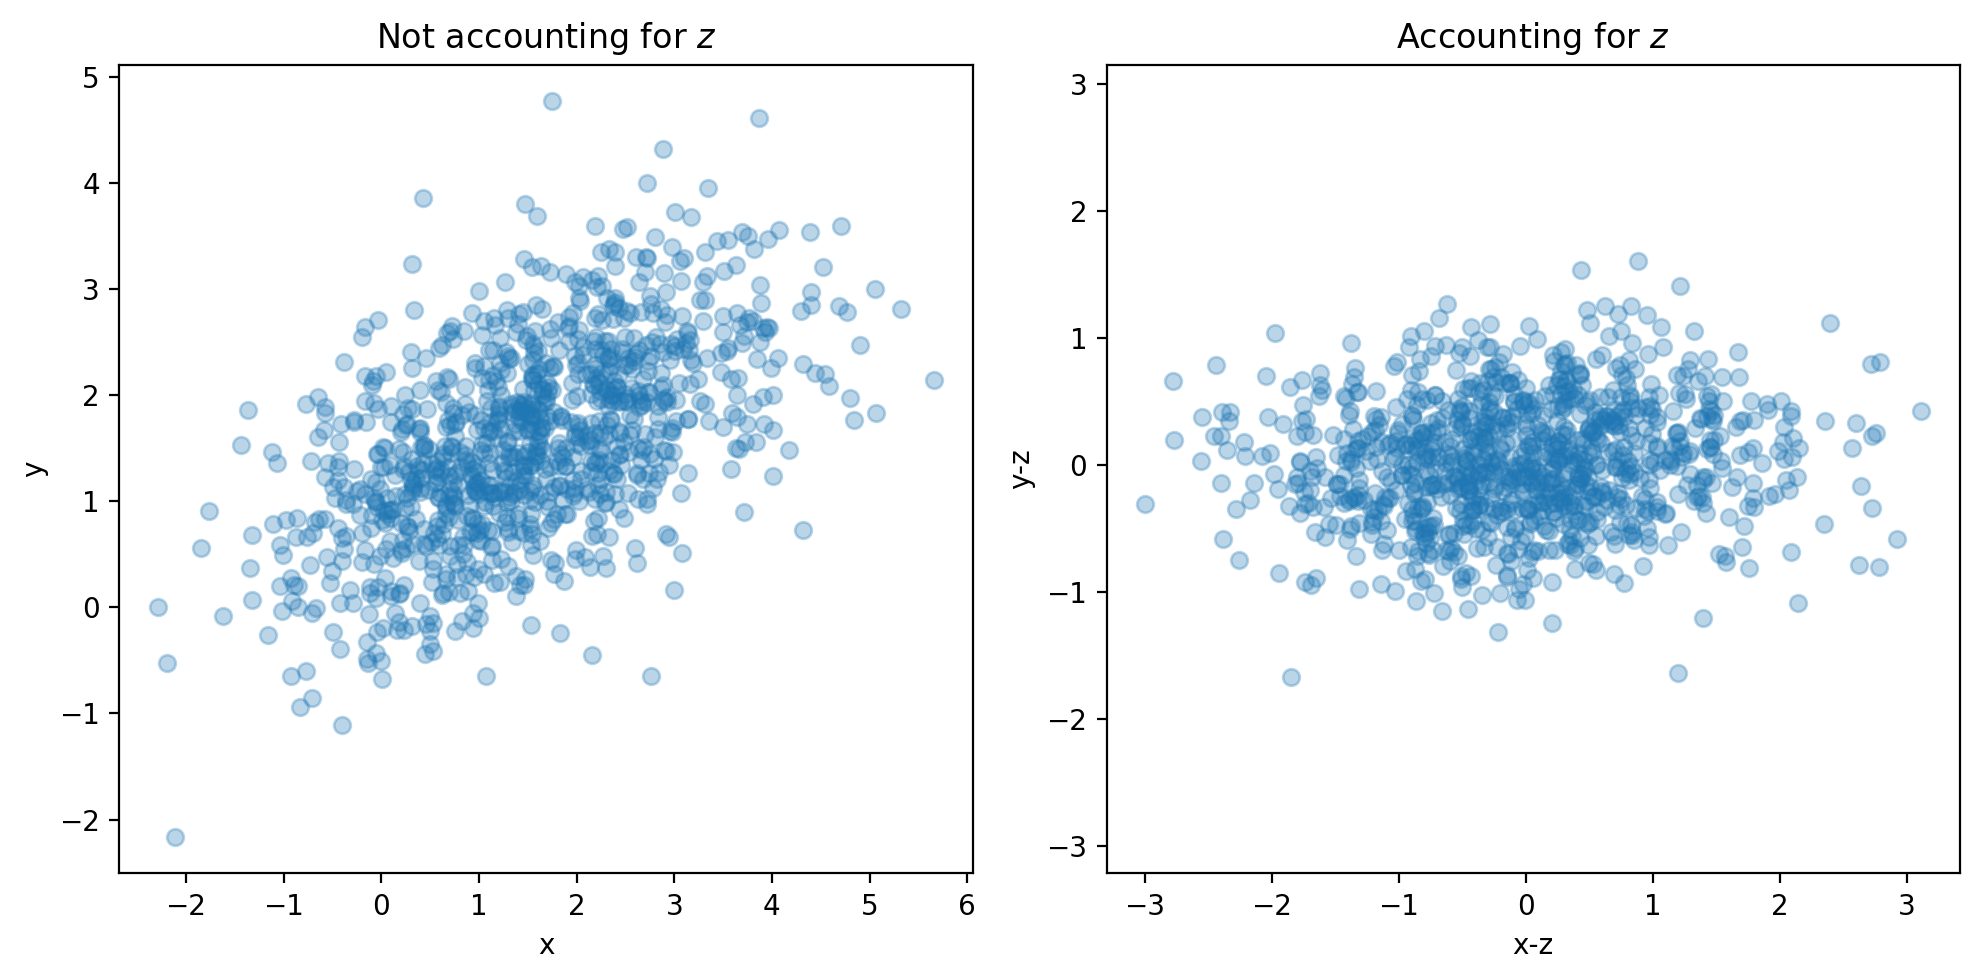

In [20]:
# Visual depiction of conditional indep
import numpy as np
import matplotlib.pyplot as plt

# Make figs look sharp in retinal displays
%config InlineBackend.figure_format = 'retina'


# p(x, y|z) = p(x|y, z)p(y|z) = p(x|z)p(y|z)
z = np.random.normal(loc=1.5, scale=0.8, size=1000)
x = np.random.normal(loc=z, scale=1., size=1000)
y = np.random.normal(loc=z, scale=0.5, size=1000)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axs[0].scatter(x, y, alpha=0.3)
axs[0].set(xlabel="x", ylabel="y", title="Not accounting for $z$")
axs[1].scatter(x - z, y - z, alpha=0.3)
axs[1].set(xlabel="x-z", ylabel="y-z", title="Accounting for $z$")
plt.axis("equal")
plt.tight_layout()


## Step 2: Inference

**Go to the board.**

Making use of the structure of the generative model to express the likelihood in terms of elementary likelihoods is the only new concept compared to the noisy measurement model of chapter 3. 

Posterior variance is less than variance of either likelihood. Prove.

With a flat prior in this case, the PME, MAP, *and* MLE are all the same! **Think:** Why is it the MLE as well? 

<center><img src="images/fig5-3.png" width=600></center>

## Step 3: Estimate distribution

Assuming a flat prior in cue combination:

- The PME is equal to $s$. Prove. 
- The variance of the estimate distribution is equal to $\dfrac{1}{J_1 + J_2}$. Prove (think linear combination of RVs). In other words, it's the same as the posterior variance we learned about for combining Gaussian prior and likelihood and *not* the same as the estimate distribution from Chapter 4 (i.e., $\dfrac{J}{(J + J_s)^2}$), correct? 

**Board time.**

## 5.3 Artificial Cue Conflict

- Since the PME is on average equal to the true stimulus, it is difficult to distinguish between the Bayesian cue combination model and another model in which the observer uses only one cue
    - Of course, the variance across responses would help distinguish (*how so?*) but it's better to have multiple discriminating points
- In cue combination experiments, a common trick is to "secretly" introduce a conflict between the true stimuli in the two modalities&mdash;instead of just $s$, we now have $s_1$ and $s_2$
    - **Caveat:** For this to work, subject still needs to believe the measurements are coming from a single $s$
    
<center><img src="images/ernst-and-banks-fig2.png" width=500></center>

*Fig. 2a from Ernst and Banks (2002)*

## 5.3: Artificial cue conflict

- Including discrepancy between two cues allows for easy test of whether human behavior conforms with Bayesian cue combination prediction or winner-take-all type of model
- Why isn't the observer's inference of a single $s$ considered suboptimal? 
    - Even when there is truly a single $s$, the measurements from each modality will very frequently be different (why?)
    - Consider this a situation where observer is utlizing a prior based on natural statistics (e.g., when observers sees a ball hit the ground and hears a thud at same moment, nearly always coming from same event/location)
- Cue combination model only considers situations where discrepancies between cues are small enough for observer to believe - cue combination is a special case of a more general model ("causal inference" model; Ch 10)

**Board time.**

## Distributions covered in this chapter

<img src="images/table5-1.png" width=1000>

## 5.4 Generalizations: Prior, Multiple Cues

<center><img src="images/fig5-4.png" width=500></center>

**Board.**

## 5.5 Evidence Accumulation

**Start at board.**

- Multiple cues get replaced with measurements at multiple time points
- Bayesian updating of the posterior means using posterior at time $t$ as prior for time $t + 1$. 
- Several important caveats (read over on your own--ask questions at next class, if you have them)


## Summary

- Cue combination is a frequent and important perceptual activity that often happens automatically
and outside of our conscious control.
- Just like when combining a prior with a likelihood, all the Bayesian observer needs to do is
multiply two probability distributions and normalize.
- Unlike the winner-take-all strategy, the optimal Bayesian solution (posterior mean estimate)
is to weight each cue according to its reliability.
- The Bayesian model accounts for human data in a wide variety of settings.
- Cue combination illustrates that prior can be flat in an interesting Bayesian model.
- Cue combination can take place over time, in which case it is sometimes called evidence
accumulation, evidence integration, or decision-making. Across subsequent measurements,
uncertainty is reduced. The PME is a linear combination of the individual measurements,
weighted by their precisions.



## For next class

- Get started on Problem Set 4
    - Problems: 5.1, 5.2, 5.5(a-c), 5.6, 5.7 
- Recommended reading: Ernst & Banks article (Nature, 2002) 